In [1]:
from fins.terminal import *

FMP API key loaded successfully. Length: 32, First chars: ESo...
FMP rate limit interval set to 0.1 seconds


Fetching https://financialmodelingprep.com/stable/company-screener?limit=1000&marketCapMoreThan=1000000000000&apikey=ESoIbVFr73ur8H7MjaSYK8r8Ifve3b6F
Creating basket from 25 tickers


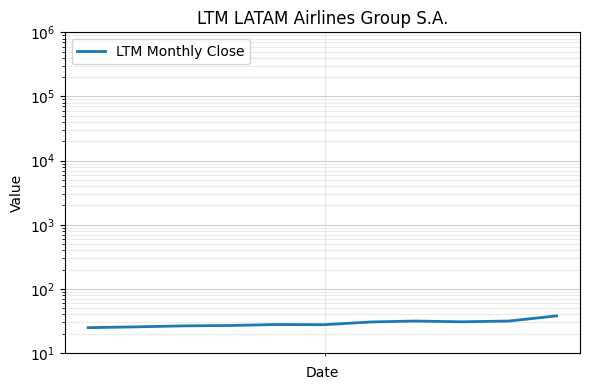

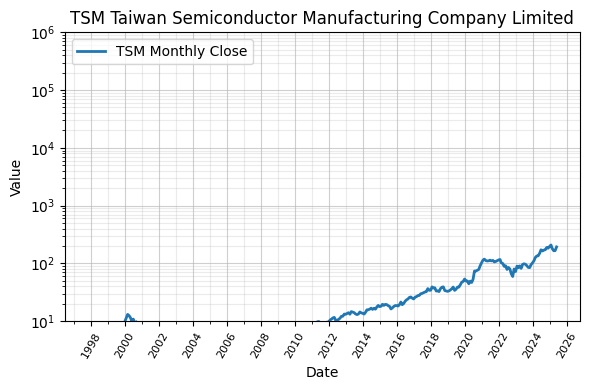

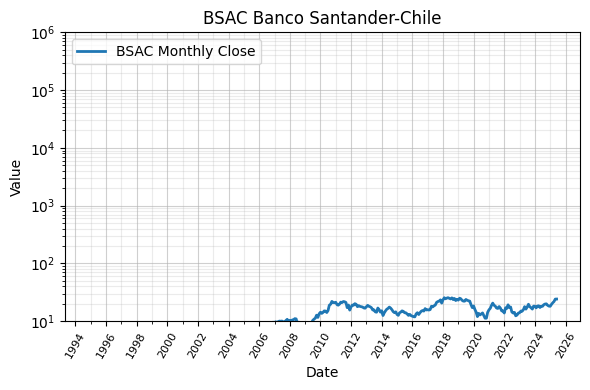

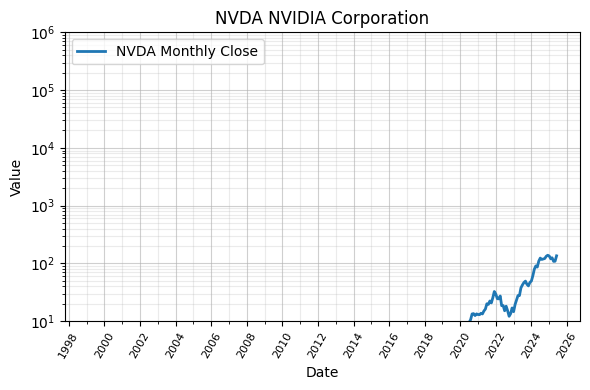

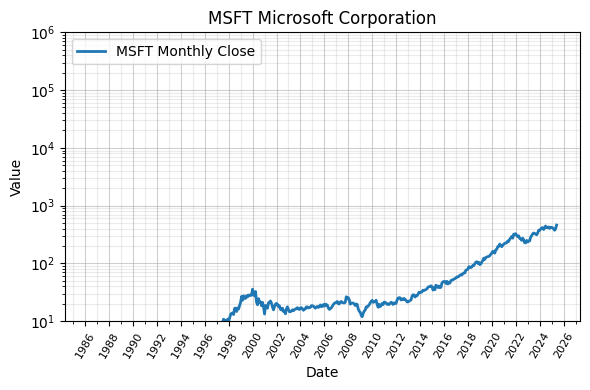

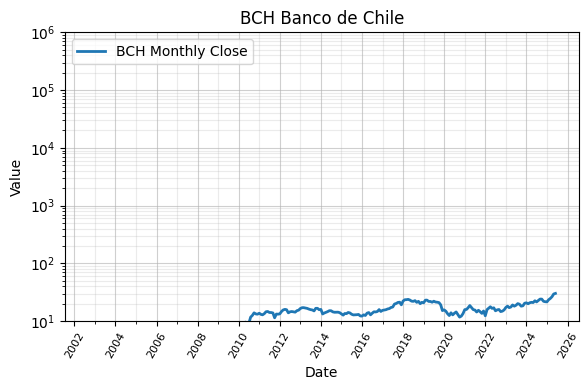

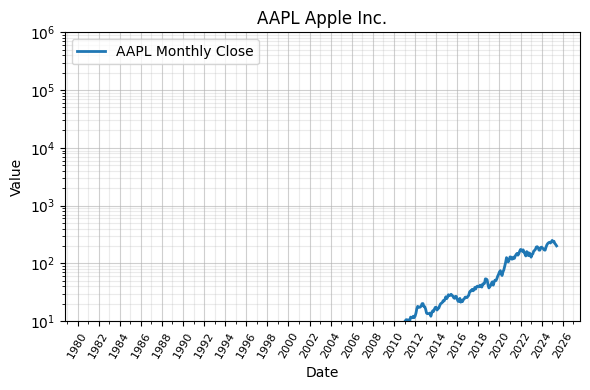

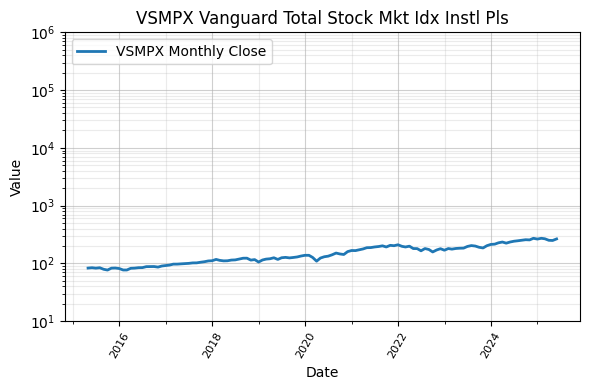

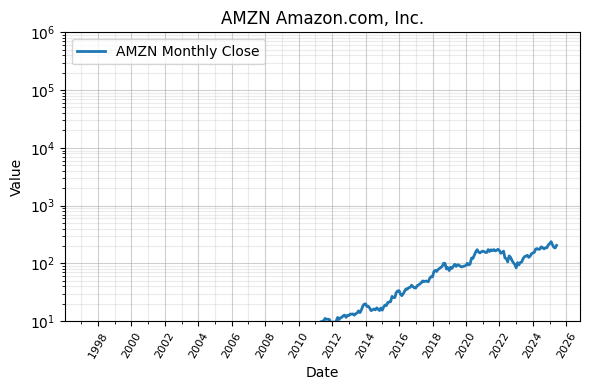

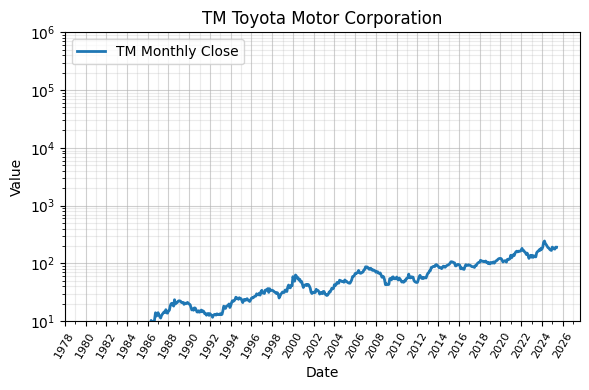

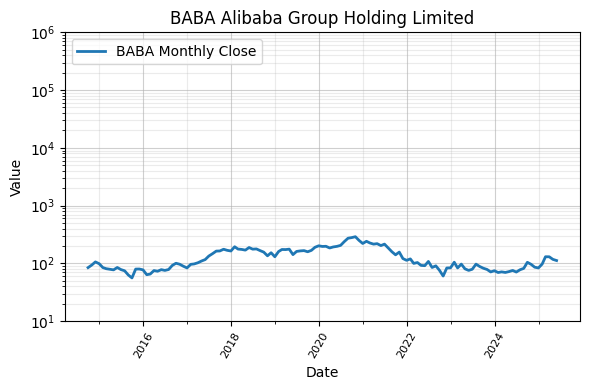

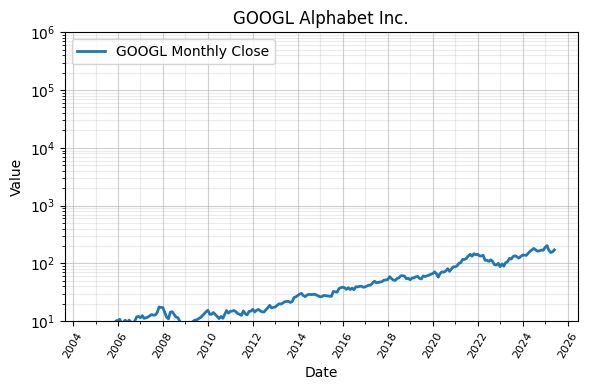

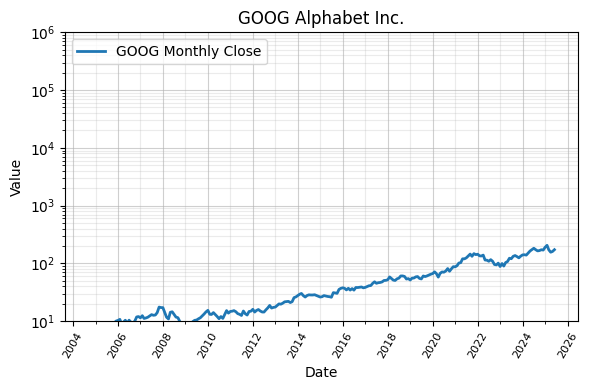

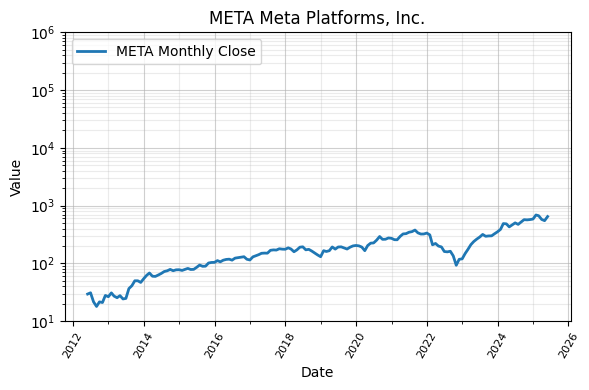

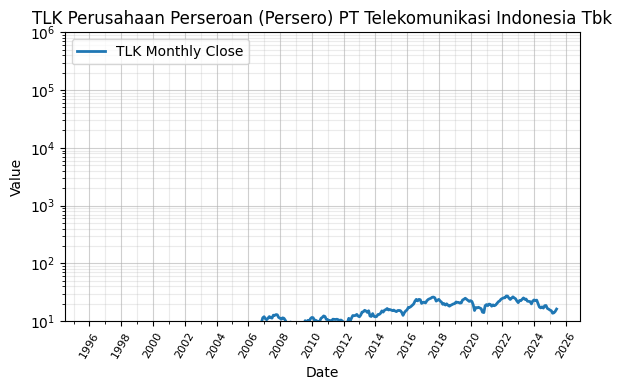

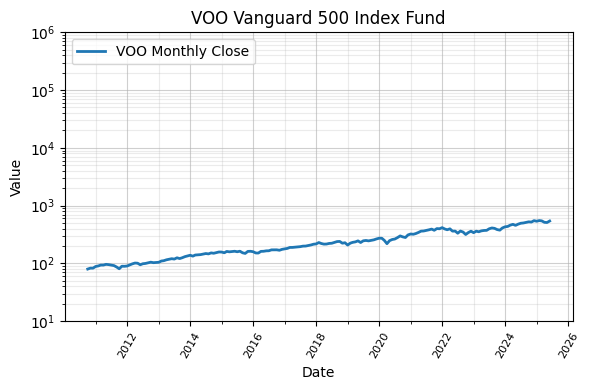

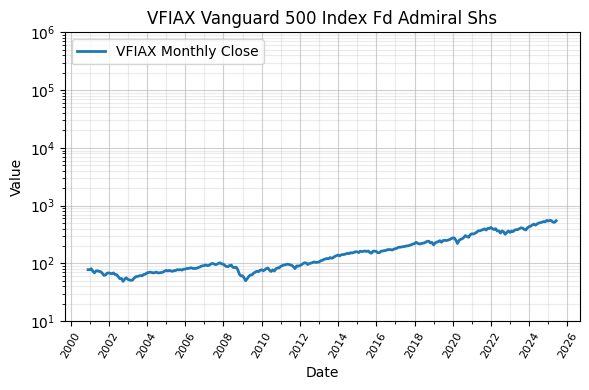

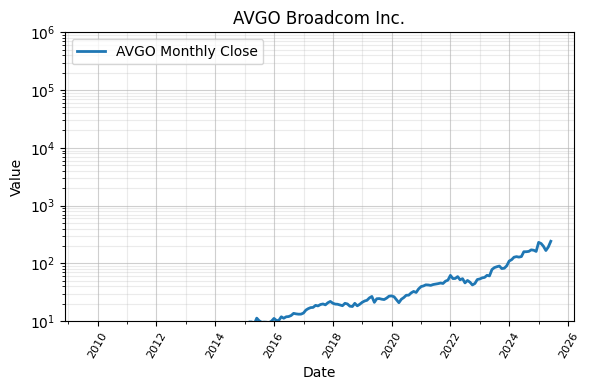

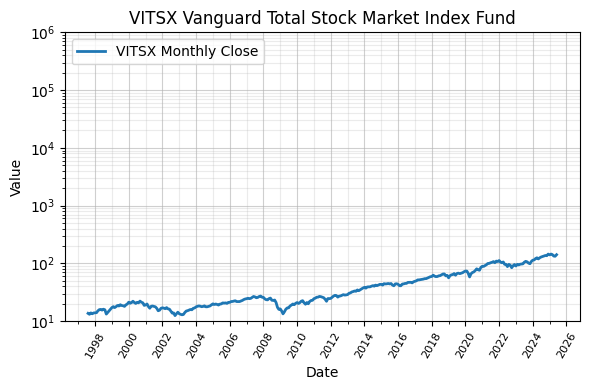

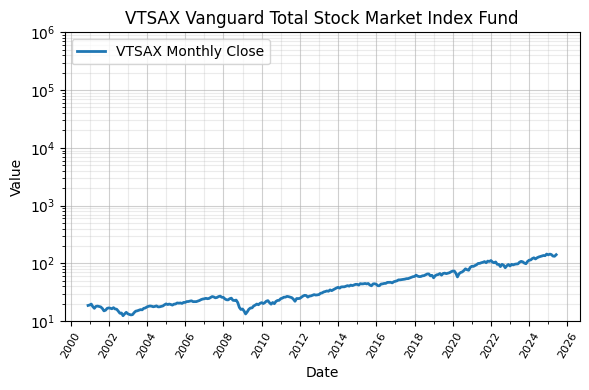

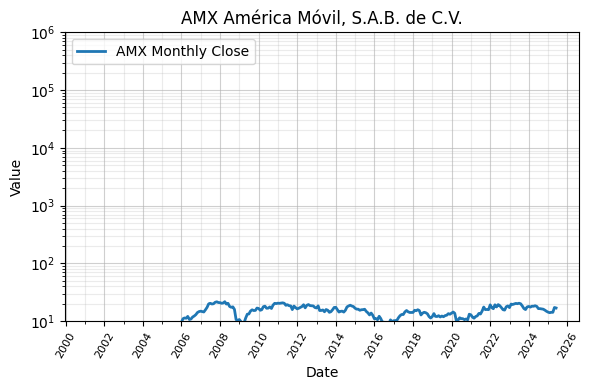

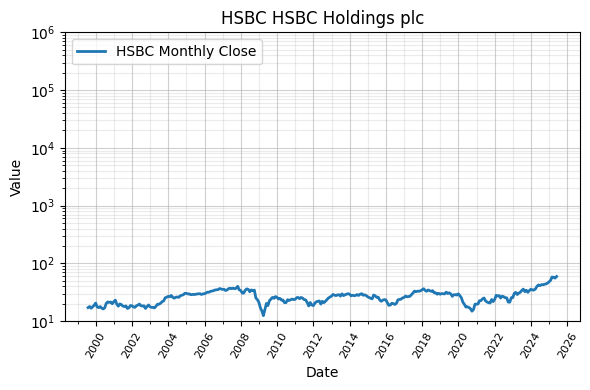

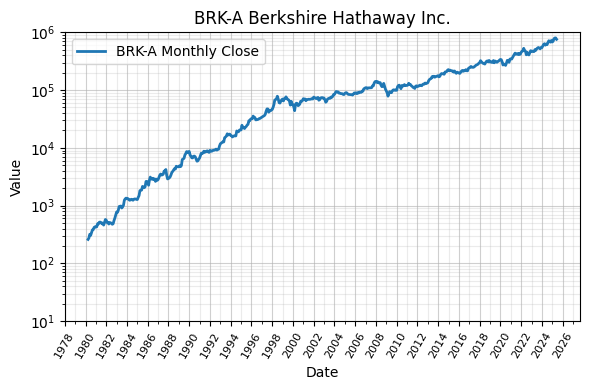

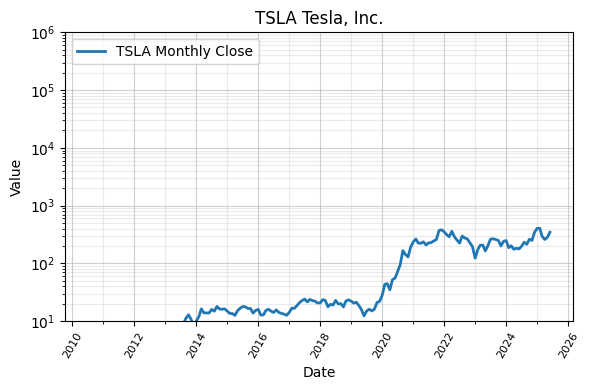

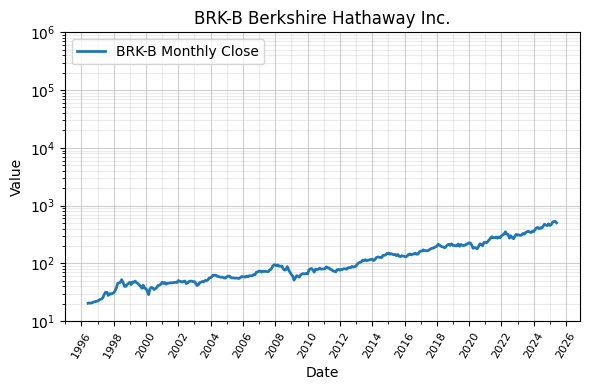

,ticker,weight,Name,MCap,CAGR
0,LTM,1.0,LATAM Airlines Group S.A.,12097826570,0.337249
1,TSM,1.0,Taiwan Semiconductor Manufacturing Company Lim...,1161832359537,0.157643
2,BSAC,1.0,Banco Santander-Chile,11561162296,0.075377
3,NVDA,1.0,NVIDIA Corporation,3782488000000,0.352166
4,MSFT,1.0,Microsoft Corporation,3612214440000,0.254625
5,BCH,1.0,Banco de Chile,15011126200,0.141111
6,AAPL,1.0,Apple Inc.,3009563700000,0.188188
7,VSMPX,1.0,Vanguard Total Stock Mkt Idx Instl Pls,2335035137535,0.114237
8,AMZN,1.0,"Amazon.com, Inc.",2183899644000,0.300411
9,TM,1.0,Toyota Motor Corporation,222654102636,0.098915


In [8]:
Screen(mcap_min = 1 * Trillion)(Name() >> Mcap() >> Cagr() >> MonthlyClose() >> PlotEach()).df()

Cropping 2 symbols to common date range...
Common date range: 1980-12-14 to 2025-06-22
Cropped 2 time series to common range


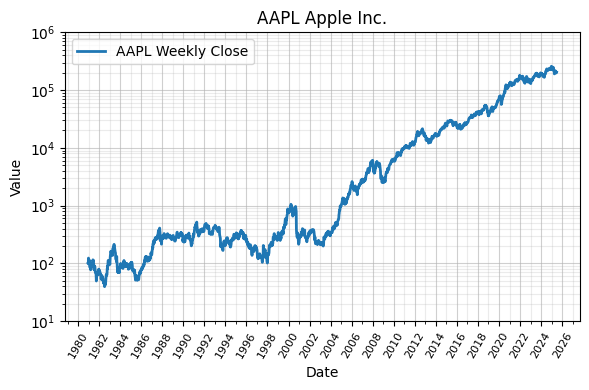

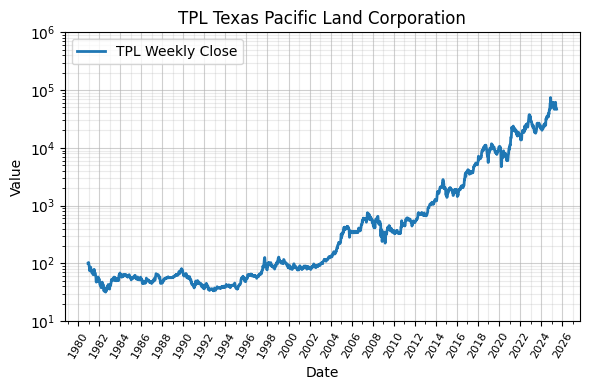

,ticker,weight,Name,Industry,Sector,CAGR[2014],CAGR[2015],CAGR[2016],CAGR[2017],CAGR[2018],CAGR[2019],CAGR[2020],CAGR[2021],CAGR[2022]
0,AAPL,1,Apple Inc.,Consumer Electronics,Technology,0.588918,0.092256,0.109128,0.548022,0.110323,0.845475,0.724206,0.289816,-0.175515
1,TPL,1,Texas Pacific Land Corporation,Oil & Gas Exploration & Production,Energy,0.513829,0.318487,1.608014,0.404889,0.382072,0.310584,-0.217471,0.819386,1.278332


In [2]:
def cagr_years(start_year, end_year):
    from functools import reduce
    from operator import rshift
    return reduce(rshift, [Cagr(year=year) for year in range(start_year, end_year + 1)])

b = Basket(AAPL, TPL)
b2 = Basket(NFLX)

p1 =  Name() >> Industry() >> Sector() >> cagr_years(2014, 2022) >> WeeklyClose() >> Crop() >> PlotEach()
p2 = Name()

b(p1).df()




